In [1]:

import os
# %env NX_CUGRAPH_AUTOCONFIG=True

import networkx as nx
import pandas as pd
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# nx.config.backend_priority = ["cugraph"] # remeber to add this into python script

#define some constants (file paths)
with open("../constants.json") as f:
    CONSTANTS = json.load(f)
    print(CONSTANTS)

PATH_TO_CONSTANTS = "../"

{'graphml': '_graph/graph.graphml', 'nodes_csv': '_graph/kg_nodes.csv', 'oregano_v3': '_graph/OREGANO_V3.tsv', 'cleaned_nodes_csv': '_graph/oregano_clenaed_nodes_new.csv', 'edges_csv': '_graph/kg_edges.csv', 'cleaned_edges_csv': '_graph/kg_edges.csv', 'graphlets': '1-kg_processing/graphlet_extraction/graphlets.json', 'templates': '_generation_templates/templates.jsonl', 'templates_metadata': '_generation_templates/templates_metadata.json', 'generation_templates': '_templates/for_generation.json', 'figures': '_figures/', 'model_paths': '/beegfs/client/default/dl-models/turbomind/', 'llm_outs': '_llm_outs'}


In [2]:
with open(f"{PATH_TO_CONSTANTS}{CONSTANTS['llm_outs']}/FILTER_DATASET/filtered_ds.jsonl", "r") as file:
    ds = [json.loads(line) for line in file]  

In [3]:
ds[0]

{'id': 2,
 'nodes': ['PATHWAY:335', 'PATHWAY:384', 'GENE:35697', 'GENE:33863'],
 'edges': [[2, 1], [2, 0], [3, 1], [3, 0]],
 'graphlet_id': 5,
 'edge_labels': ['acts_within', 'acts_within', 'acts_within', 'acts_within'],
 'node_names': ['Orc1 removal from chromatin',
  'Degradation of DVL',
  'proteasome 26S subunit, non-ATPase 6',
  'SEM1 26S proteasome subunit'],
 'graphlet_text': [' - 0: Orc1 removal from chromatin \n',
  ' - 1: Degradation of DVL \n',
  ' - 2: proteasome 26S subunit, non-ATPase 6 \n',
  ' - 3: SEM1 26S proteasome subunit \n'],
 'num_nodes': 4,
 'graphlet_index': 3,
 'text': '**Analysis of Graphlet**\n\n* **Question Node:** Orc1 removal from chromatin (Node 0) - This node provides the context for inquiry, focusing on a specific biological process.\n* **Hidden Nodes:**\n\t+ proteasome 26S subunit, non-ATPase 6 (Node 2)\n\t+ SEM1 26S proteasome subunit (Node 3) - These nodes act as logical intermediaries, enabling multi-hop reasoning.\n* **Answer Node:** Degradation o

In [4]:
ds[0]

node_dict  = {}

set_of_nodes = set()
for i in ds:
    for index,n in enumerate(i['nodes']):
        set_of_nodes.add(n)
        node_dict[n] = i['node_names'][index]
print(len(set_of_nodes))

18954


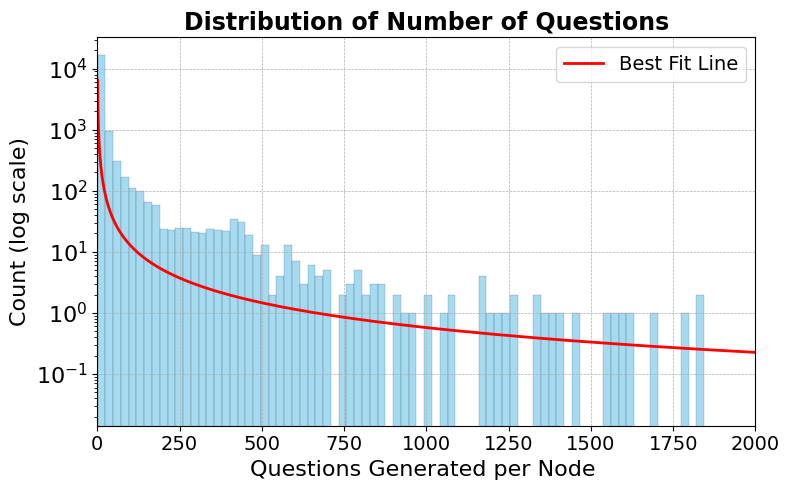

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from scipy.stats import linregress

# Count node frequencies
node_counts = Counter()
for item in ds:
    for node in item['nodes']:
        node_counts[node] += 1

# List of how often each node appears
frequencies = list(node_counts.values())

# Get the x and y for the histogram (frequency data)
x = np.array(sorted(frequencies))
y = np.array([frequencies.count(i) for i in x])

# Log-transform the y values (log scale for the y-axis)
log_y = np.log(y)

# Perform linear regression on the log-transformed data (log-log fit)
slope, intercept, _, _, _ = linregress(np.log(x), log_y)

# Generate the best fit line
best_fit_line = np.exp(intercept) * x**slope

# Plot the histogram

# Create the plot with custom font sizes
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(frequencies, bins=400, kde=False, color="skyblue", ax=ax)

# Plotting the line of best fit
ax.plot(x, best_fit_line, color='red', linestyle='-', linewidth=2, label='Best Fit Line')

# Set axis labels and title with specified font sizes
ax.set_xlabel('Questions Generated per Node ', fontsize=16)
ax.set_ylabel('Count (log scale)', fontsize=16)
ax.set_title('Distribution of Number of Questions', fontsize=17, fontweight='bold')

# Set x and y axis limits
ax.set_xlim(0, 2000)
ax.set_yscale('log')

# Customize tick label sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=16)

# Add legend with custom font size
ax.legend(fontsize=14)

# Customize grid
ax.grid(True, which="major", ls="--", linewidth=0.5)

plt.tight_layout()
plt.savefig(PATH_TO_CONSTANTS+CONSTANTS['figures']+"Node_Question_Distribution.pdf", format='pdf', dpi=300)  # Export with high resolution
plt.show()

In [12]:
filtered_counts = {node: count for node, count in node_counts.items() if count > 2000}


# Sort the filtered counts by the count value (ascending order)
sorted_filtered_counts = dict(sorted(filtered_counts.items(), key=lambda item: item[1]))

# Display the sorted filtered node counts
print(sorted_filtered_counts)
print(len(filtered_counts))

{'COMPOUND:11846': 2051, 'COMPOUND:90060': 2079, 'EFFECT:67': 2177, 'DISEASE:3210': 2178, 'DISEASE:3209': 2341, 'GENE:4365': 2354, 'DISEASE:1420': 2797, 'COMPOUND:13853': 2836, 'COMPOUND:1750': 3375, 'DISEASE:1468': 3466, 'COMPOUND:59': 3637, 'COMPOUND:89878': 3720, 'COMPOUND:5854': 3849, 'COMPOUND:10692': 4023, 'COMPOUND:5517': 4064, 'COMPOUND:10862': 4076, 'COMPOUND:10467': 4077, 'COMPOUND:5689': 4113, 'COMPOUND:9626': 4169, 'COMPOUND:10719': 4182, 'COMPOUND:12414': 4261, 'COMPOUND:5289': 4301, 'COMPOUND:9580': 4380, 'COMPOUND:10162': 4417, 'COMPOUND:4875': 4468, 'COMPOUND:10716': 4482, 'COMPOUND:21': 4498, 'COMPOUND:8062': 4551, 'COMPOUND:3199': 4695, 'COMPOUND:8143': 4860, 'COMPOUND:78': 4938, 'COMPOUND:8': 5072, 'COMPOUND:4960': 5159, 'COMPOUND:11059': 5255, 'COMPOUND:19': 5592, 'COMPOUND:7846': 5734, 'COMPOUND:7856': 5881, 'DISEASE:1740': 6694, 'COMPOUND:8047': 6859, 'EFFECT:46': 7268, 'COMPOUND:90749': 9454}
41


In [13]:
for node, count in sorted_filtered_counts.items():
    # Get the name from node_dict using the node as the key
    node_name = node_dict.get(node, "Unknown")  # Default to "Unknown" if node not in node_dict
    
    # Print node, count, and corresponding name from node_dict
    print(f"{node} {node_name} {count}  ")

COMPOUND:11846 Medical_cannabis 2051  
COMPOUND:90060 Ethanol 2079  
EFFECT:67 pseudotumor cerebri 2177  
DISEASE:3210 Transplant rejection 2178  
DISEASE:3209 Transplantation - action 2341  
GENE:4365 cytochrome P450, family 3, subfamily A 2354  
DISEASE:1420 Chronic hepatitis C 2797  
COMPOUND:13853 Letibotulinumtoxina 2836  
COMPOUND:1750 Propylene_glycol 3375  
DISEASE:1468 Human immunodeficiency virus infection 3466  
COMPOUND:59 Adenosine_deaminase 3637  
COMPOUND:89878 SangCyA 3720  
COMPOUND:5854 Polidocanol 3849  
COMPOUND:10692 Cepeginterferon alfa-2B 4023  
COMPOUND:5517 Pegnivacogin 4064  
COMPOUND:10862 Neosaxitoxin 4076  
COMPOUND:10467 Lexaptepid pegol 4077  
COMPOUND:5689 Pegsunercept 4113  
COMPOUND:9626 Olaptesed Pegol 4169  
COMPOUND:10719 Pegamotecan 4182  
COMPOUND:12414 Elapegademase 4261  
COMPOUND:5289 Peginterferon alfacon-1 4301  
COMPOUND:9580 Eptacog alfa pegol (activated) 4380  
COMPOUND:10162 Abicipar Pegol 4417  
COMPOUND:4875 Egaptivon pegol 4468  
COMPO

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Extract raw values and apply log scale transformation
nodes = list(node_counts.keys())
values = np.array(list(node_counts.values()), dtype=float)

# Add small constant to avoid log(0)
log_values = np.log10(values + 1e-6)

# Normalize log-transformed values to 0–1
norm = (log_values - log_values.min()) / (log_values.max() - log_values.min() + 1e-6)

# Map to matplotlib colormap (e.g., 'plasma', 'viridis', 'hot')
cmap = plt.get_cmap('plasma')
colors = [mcolors.to_hex(cmap(v)) for v in norm]

# Optionally map to sizes
min_size, max_size = 10, 40
sizes = min_size + (max_size - min_size) * norm

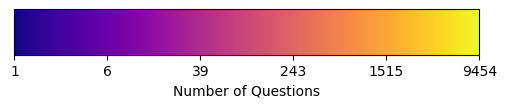

In [18]:

# Normalize log values
norm = mcolors.Normalize(vmin=log_values.min(), vmax=log_values.max())
cmap = plt.get_cmap('plasma')

# Make colorbar
fig, ax = plt.subplots(figsize=(6, 1.2))
fig.subplots_adjust(bottom=0.5)

# Create scalar mappable and colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cb = plt.colorbar(sm, cax=ax, orientation='horizontal')

# Set label
cb.set_label('Number of Questions')

# Custom ticks (pick 5–7 points evenly spaced in log space)
tick_locs = np.linspace(log_values.min(), log_values.max(), 6)
tick_labels = [f'{int(round(10**val))}' for val in tick_locs]

cb.set_ticks(tick_locs)
cb.set_ticklabels(tick_labels)

# plt.title("Color Key (Original Scale)")
plt.savefig("tmp.png")
plt.show()


In [19]:
# reconstruct graph and add node colors
# Initialize an empty directed graph to represent the entire knowledge graph (KG)
kg = nx.DiGraph()

# Iterate over each dictionary in ds
for elem in ds:
    # Add nodes to the graph (nodes are unique, so duplicates will be automatically handled)
    kg.add_nodes_from(elem['nodes'])

    # Add edges to the graph
    kg.add_edges_from([(elem['nodes'][edge[0]], elem['nodes'][edge[1]]) for edge in elem['edges']])

# Print the final knowledge graph's nodes and edges
print("Nodes in the final knowledge graph:")
print(len(kg.nodes))

print("\nEdges in the final knowledge graph:")
print(len(kg.edges))

Nodes in the final knowledge graph:
18954

Edges in the final knowledge graph:
65015


In [10]:
for node, color, size in zip(nodes, colors, sizes):
    if node in kg:
        kg.nodes[node]['color'] = color
        kg.nodes[node]['size'] = size
        kg.nodes[node]['title'] = f"{node}: {node_counts[node]}"

In [36]:
from pvsvg import Network
import networkx as nx

import random

def weighted_sample_graph_from_counter(G, node_counts: dict, num_nodes: int):
    # Get the intersection of Counter keys and nodes in G
    valid_nodes = [n for n in node_counts if n in G]
    
    if len(valid_nodes) < num_nodes:
        raise ValueError(f"Not enough nodes to sample: requested {num_nodes}, but only {len(valid_nodes)} valid nodes.")

    weights = np.array([node_counts[n] for n in valid_nodes], dtype=float)
    probs = weights / weights.sum()

    sampled_nodes = np.random.choice(valid_nodes, size=num_nodes, replace=False, p=probs)
    subgraph = G.subgraph(sampled_nodes).copy()

    return subgraph

sampled_G = weighted_sample_graph_from_counter(kg,node_counts,2000)  # Or use bfs_sample(G, 'some_node_id', 1000)

net = Network(sampled_G, width=1500)
# net.from_nx(sampled_G)

# Optional: fine-tune layout
# net.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=100, spring_strength=0.08)

# Generate and show
# net.show('kg_downsampled.html')
# display(HTML('kg_downsampled.html'))
# net.save_graph("my_kg_graph.html")

net.draw("test.html")


In [24]:

graphml_path = PATH_TO_CONSTANTS+CONSTANTS['graphml']
G = nx.read_graphml(graphml_path)

In [27]:
nodes_to_remove = [n for n, d in G.nodes(data=True) if pd.isna(d.get('name'))]
G.remove_nodes_from(nodes_to_remove)

nodes_to_remove = [node for node, degree in G.degree() if degree > 100 or degree < 3]
red_KG = G.copy()
red_KG.remove_nodes_from(nodes_to_remove)

In [20]:
red_degrees = dict(kg.degree())
# red_degrees = dict(G.degree())

# filter_deg = dict(kg.degree())

In [21]:
# Sort both full dictionaries
sorted_counts = sorted(node_counts.items(), key=lambda item: item[1], reverse=True)
sorted_red = sorted(red_degrees.items(), key=lambda item: item[1], reverse=True)

# Build rank + value lookup
rank_counts = {node: rank + 1 for rank, (node, _) in enumerate(sorted_counts)}
rank_red = {node: rank + 1 for rank, (node, _) in enumerate(sorted_red)}

value_counts = dict(node_counts)
value_red = dict(red_degrees)

# Top 10 from node_counts
top_10_count_nodes = [node for node, _ in sorted_counts[50:100]]

# Print comparison
for node in top_10_count_nodes:
    print(
        f"{rank_counts[node]:2d}.: {node}, Number of questions: {value_counts[node]:3d} "
        f"| Degree position in Reduced KG (ranked by degree): {rank_red.get(node, '—'):>2}, Degree Value: {value_red.get(node, '—')}"
    )


51.: COMPOUND:9357, Number of questions: 1414 | Degree position in Reduced KG (ranked by degree): 529, Degree Value: 44
52.: COMPOUND:11087, Number of questions: 1379 | Degree position in Reduced KG (ranked by degree): 535, Degree Value: 44
53.: GENE:9115, Number of questions: 1371 | Degree position in Reduced KG (ranked by degree): 1357, Degree Value: 23
54.: DISEASE:123, Number of questions: 1343 | Degree position in Reduced KG (ranked by degree): 646, Degree Value: 40
55.: DISEASE:828, Number of questions: 1330 | Degree position in Reduced KG (ranked by degree): 532, Degree Value: 44
56.: GENE:23279, Number of questions: 1267 | Degree position in Reduced KG (ranked by degree): 725, Degree Value: 37
57.: COMPOUND:896, Number of questions: 1258 | Degree position in Reduced KG (ranked by degree): 533, Degree Value: 44
58.: GENE:8531, Number of questions: 1252 | Degree position in Reduced KG (ranked by degree): 880, Degree Value: 33
59.: GENE:16112, Number of questions: 1213 | Degree po

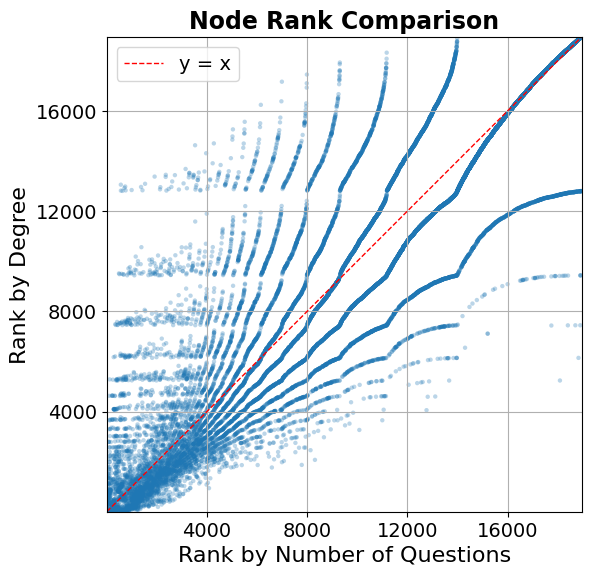

In [34]:
from matplotlib.ticker import MaxNLocator

all_nodes = list(node_counts.keys())

#  = rank in full data, Y = rank in reduced KG
x = [rank_counts[node] for node in all_nodes]
y = [rank_red.get(node, np.nan) for node in all_nodes]

# Get max rank for consistent square limits
max_rank = max(max(x), max(y))

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, alpha=0.3, s=10, edgecolors='none')

# Reference line y = x
ax.plot([1, max_rank], [1, max_rank], color='red', linestyle='--', linewidth=1, label='y = x')

# Square limits and aspect
ax.set_xlim(1, max_rank)
ax.set_ylim(1, max_rank)
ax.set_aspect('equal')

# ✅ Force same number of ticks on both axes
n_ticks = 6
ax.xaxis.set_major_locator(MaxNLocator(n_ticks))
ax.yaxis.set_major_locator(MaxNLocator(n_ticks))

# Labels and style
ax.set_xlabel("Rank by Number of Questions", fontsize=16)
ax.set_ylabel("Rank by Degree", fontsize=16)
ax.set_title("Node Rank Comparison", fontsize=17, fontweight='bold')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=14)
ax.grid(True)

plt.tight_layout()

# Save the figure
plt.savefig(PATH_TO_CONSTANTS + CONSTANTS['figures'] + "Node_Rank.pdf", format='pdf', dpi=300)

plt.show()

In [47]:
"COMPOUND:7856" in nodes_to_remove

True